In [272]:
import warnings
warnings.filterwarnings("ignore")

In [273]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Loading Titanic dataset from seaborn

In [274]:
df = sns.load_dataset("titanic")

In [275]:
# Data
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [276]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


🔍Q1. Descriptive Statistics
Print:

Number of rows and columns

Data types of each column

Summary statistics for numerical columns

In [277]:
# Data Dimensions and Types
print(f"Number of rows: {(df.shape)[0]}")
print(f"Number of columns: {(df.shape)[1]}")
# Data types of all columns
print(df.dtypes)

Number of rows: 891
Number of columns: 15
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


In [278]:
# Summary statistics
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [279]:
# Changing type to category
df.survived = df.survived.astype('category')
df.pclass = df.pclass.astype('category')
df.sex = df.sex.astype('category')
df.sibsp = df.sibsp.astype('category')
df.embarked = df.embarked.astype('category')
df.parch = df.parch.astype('category')
df['class'] = df['class'].astype('category')
df.who = df.who.astype('category')
df.adult_male = df.adult_male.astype('category')
df.deck = df.deck.astype('category')
df.alive = df.alive.astype('category')
df.alone = df.alone.astype('category')

In [280]:
df.describe()

,age,fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


📊 Q2. Visualize Distribution
Plot a histogram for age and describe the distribution shape.

Is it skewed? (Use .skew() or visual inspection)

Bonus: Use sns.kdeplot() for a smooth curve.

| Skewness Value | Interpretation          |
| -------------- | ----------------------- |
| = 0            | Symmetrical             |
| 0 < skew < 1   | Moderately right-skewed |
| > 1            | Highly right-skewed     |
| -1 < skew < 0  | Moderately left-skewed  |
| < -1           | Highly left-skewed      |

In [281]:
# Skewness
sk = round(df.age.skew(), 2)
if sk == 0:
    print(f"{sk}: Normal Distribution")
elif sk > 0 and sk < 1:
    print(f"{sk}: Moderately right-skewed")
elif sk > 1:
    print(f"{sk}: Highly right-skewed")
elif sk > -1 and sk < 0:
    print(f"{sk}: Modelrately left-skewed")
elif sk < -1:
    print(f"{sk}: Highly left-skewed")

0.39: Moderately right-skewed


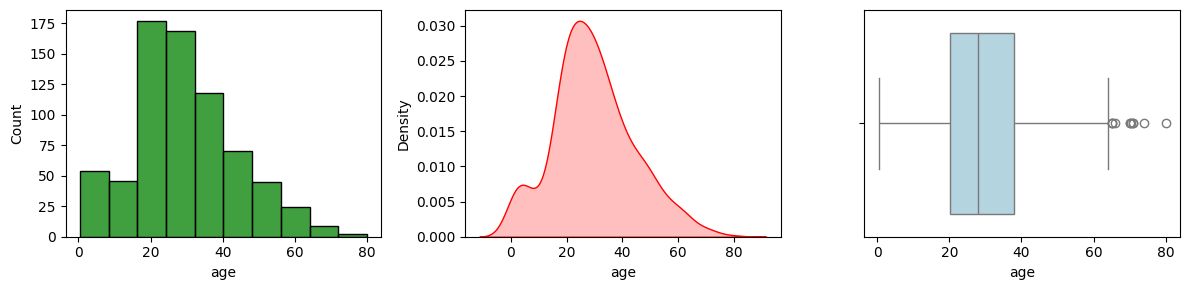

In [282]:
# Age Distribution
plt.figure(figsize=(12, 3))
plt.subplot(1,3,1)
sns.histplot(data=df, x='age', color='green', bins=10)
plt.subplot(1,3,2)
sns.kdeplot(data=df, x='age', color='red', fill=True)
plt.subplot(1,3,3)
sns.boxplot(data=df, x='age', color='lightblue')
plt.tight_layout()
plt.show()


⚠️ Q3. Detect Outliers in "fare"

Use IQR method to find outliers in the fare column.

How many outliers are there?

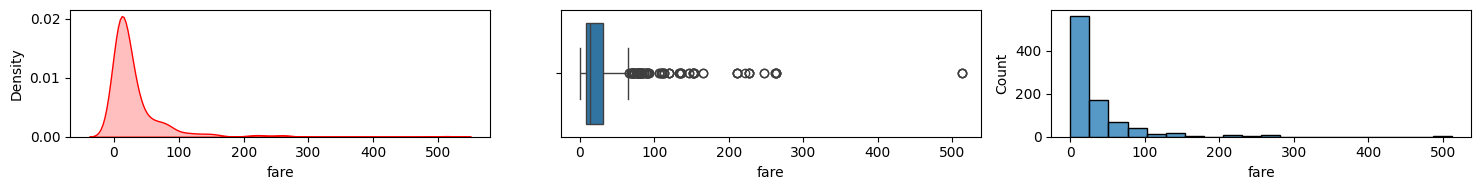

In [283]:
plt.figure(figsize=(15,2))
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x='fare', fill=True, color='red')
plt.subplot(1, 3, 2)
sns.boxplot(data=df, x='fare')
plt.subplot(1, 3, 3)
sns.histplot(data=df, x='fare', bins=20)
plt.tight_layout()
plt.show()

In [284]:
q1 = df.age.quantile(0.25)
q3 = df.age.quantile(0.75)
iqr = q3 - q1
lb = q1 - (1.5*iqr)
ub = q3 + (1.5*iqr)
outliers = list(df.loc[(df.fare > ub) | (df.fare < lb), 'fare'].values)
print(f"25th percentile: {q1}")
print(f"75th percentile: {q3}")
print(f"Interquartile range: {iqr}")
print(f"Lower bound: {lb}")
print(f"Upper bound: {ub}")
print(f"Outliers: {outliers}")

25th percentile: 20.125
75th percentile: 38.0
Interquartile range: 17.875
Lower bound: -6.6875
Upper bound: 64.8125
Outliers: [71.2833, 263.0, 146.5208, 82.1708, 76.7292, 80.0, 83.475, 73.5, 263.0, 77.2875, 247.5208, 73.5, 77.2875, 79.2, 66.6, 69.55, 69.55, 146.5208, 69.55, 113.275, 76.2917, 90.0, 83.475, 90.0, 79.2, 86.5, 512.3292, 79.65, 153.4625, 135.6333, 77.9583, 78.85, 91.0792, 151.55, 247.5208, 151.55, 110.8833, 108.9, 83.1583, 262.375, 164.8667, 134.5, 69.55, 135.6333, 153.4625, 133.65, 66.6, 134.5, 263.0, 75.25, 69.3, 135.6333, 82.1708, 211.5, 227.525, 73.5, 120.0, 113.275, 90.0, 120.0, 263.0, 81.8583, 89.1042, 91.0792, 90.0, 78.2667, 151.55, 86.5, 108.9, 93.5, 221.7792, 106.425, 71.0, 106.425, 110.8833, 227.525, 79.65, 110.8833, 79.65, 79.2, 78.2667, 153.4625, 65.0, 77.9583, 69.3, 76.7292, 73.5, 113.275, 133.65, 73.5, 512.3292, 76.7292, 211.3375, 110.8833, 227.525, 151.55, 227.525, 211.3375, 512.3292, 78.85, 262.375, 71.0, 65.0, 86.5, 120.0, 77.9583, 211.3375, 79.2, 69.55, 12

Q4. Missing Value Imputation

How many missing values are in the dataset?

Impute missing values in:

age using median

embarked using mode

In [285]:
df.isna().sum()[df.isna().sum() > 0]

age            177
embarked         2
deck           688
embark_town      2
dtype: int64

age, embarked, deck & embark_town have missing values

In [286]:
# Imputing missing values in age
print(f"Age mean: {df.age.mean()}")
print(f"Median age: {df.age.median()}")

Age mean: 29.69911764705882
Median age: 28.0


Mean and median of age are very close to each other

since mean is bit larger than median suggests a moderate right skewness

In [287]:
# Imputing age with median
df.age.fillna(df.age.median(), inplace=True)

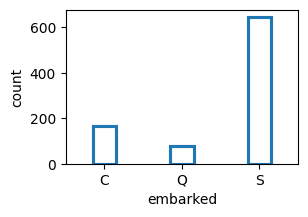

In [301]:
# Imputing missing values in embarked
plt.figure(figsize=(3,2))
sns.countplot(data=df, x='embarked', fill=False, width=0.3)
plt.show()

'S' appears to be most common value

In [289]:
df.embarked.fillna(df.embarked.mode()[0], inplace=True)

In [290]:
(df.isna().sum())[df.isna().sum() > 0]

deck           688
embark_town      2
dtype: int64

🔬 Q5. Hypothesis Testing – Survival vs Class

Are survival and passenger class independent?

Build a contingency table of survived vs pclass

Run a chi-square test of independence

Report:

Chi-square statistic

p-value

Conclusion at α = 0.05

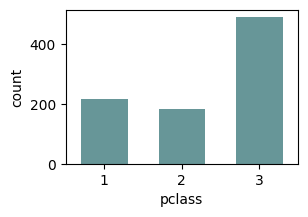

In [327]:
plt.figure(figsize=(3,2))
sns.countplot(data=df, x='pclass', fill=True, width=0.6, color='cadetblue')
plt.show()

In [322]:
df.pclass.value_counts()

pclass
3    491
1    216
2    184
Name: count, dtype: int64

Both 'pclass' and 'survived' are categorical variables, running chi-square test

Null Hypothesis H0: Surival of the passenger has no relation with the class, any difference is by chance alone

In [320]:
from scipy.stats import chi2_contingency

In [313]:
contingency_matrix = pd.crosstab(df.pclass, df.survived)

In [328]:
stat, p, dof, expected = chi2_contingency(contingency_matrix)

In [338]:
print(f"Chi-Square statistic: {stat}")
print(f"p-value: {p:10f}")
print(f"Degree of freedom: {dof}")
print(f"Expected frequencies: {expected}")
print(f"{'H0: Rejected' if p < 0.05 else 'H1: Accepted'}")

Chi-Square statistic: 102.88898875696056
p-value:   0.000000
Degree of freedom: 2
Expected frequencies: [[133.09090909  82.90909091]
 [113.37373737  70.62626263]
 [302.53535354 188.46464646]]
H0: Rejected


H0 is rejected, there seems to be some relation between the class of a passenger and the survival